# Late Fusion by Ambiguity Groups (No Temporal Behavior Features)

This notebook splits trials into ambiguity groups (Low/Medium/High) and runs late fusion separately for each group.

**Note**: This version excludes reaction_time, decision_time, and ambiguity from behavioral features.

**Parameterized**: Set `TIMEFRAME` to run PRE or POST analysis.

In [1]:
# ============================================================================
# CONFIGURATION: Set timeframe for analysis
# ============================================================================
TIMEFRAME = 'PRE'  # Change to 'POST' for post-decision analysis
# ============================================================================

import sys
sys.path.append('../..')  # Add project root to path

import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import from src package
from src.models.fusion import weighted_late_fusion

np.random.seed(42)
sns.set_style('whitegrid')

print(f"\n{'='*70}")
print(f"AMBIGUITY GROUP ANALYSIS (NO TEMPORAL BEHAVIOR): {TIMEFRAME}-DECISION PERIOD")
print(f"Excluded behavior features: reaction_time, decision_time, ambiguity")
print(f"{'='*70}\n")


AMBIGUITY GROUP ANALYSIS (NO TEMPORAL BEHAVIOR): PRE-DECISION PERIOD
Excluded behavior features: reaction_time, decision_time, ambiguity



## 1. Load Pre-Extracted Features

In [2]:
# Load pre-extracted features
with open(f'../../data/results/features_{TIMEFRAME}/extracted_features_{TIMEFRAME}.pkl', 'rb') as f:
    feature_data = pickle.load(f)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols_original = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

# EXCLUDE reaction_time, decision_time, and ambiguity from behavior features
excluded_features = ['reaction_time', 'decision_time', 'ambiguity']
behavior_cols = [col for col in behavior_cols_original if col not in excluded_features]

print(f"Loaded {len(merged_df)} trials from {merged_df['subject_id'].nunique()} subjects")
print(f"  Features extracted on: {feature_data['metadata']['extraction_date']}")
print(f"\nOriginal behavior features: {behavior_cols_original}")
print(f"Excluded features: {excluded_features}")
print(f"Remaining behavior features: {behavior_cols}")
print(f"\nAmbiguity distribution:")
print(merged_df['ambiguity'].value_counts().sort_index())

Loaded 12511 trials from 97 subjects
  Features extracted on: 2026-01-10 14:16:16

Original behavior features: ['reaction_time', 'decision_time', 'ev_difference', 'invest_variance', 'ambiguity', 'condition_social', 'risk_premium']
Excluded features: ['reaction_time', 'decision_time', 'ambiguity']
Remaining behavior features: ['ev_difference', 'invest_variance', 'condition_social', 'risk_premium']

Ambiguity distribution:
ambiguity
0    4177
3    4162
6    4172
Name: count, dtype: int64


## 2. Create Ambiguity Groups

In [3]:
# Create ambiguity groups
merged_df['ambiguity_group'] = merged_df['ambiguity'].replace({0:'Low', 3:'Medium', 6:'High'})

print("\nAmbiguity group distribution:")
print(merged_df['ambiguity_group'].value_counts())


Ambiguity group distribution:
ambiguity_group
Low       4177
High      4172
Medium    4162
Name: count, dtype: int64


## 3. Prepare Feature Sets

In [4]:
print(f"Physiology ({TIMEFRAME}): {len(physio_cols)} features")
print(f"Behavior (filtered): {len(behavior_cols)} features")
print(f"Gaze: {len(gaze_cols)} features")

Physiology (PRE): 13 features
Behavior (filtered): 4 features
Gaze: 20 features


## 4. Run Late Fusion for Each Ambiguity Group

In [5]:
# Run late fusion for each ambiguity group
group_results = {}

for group in ['Low', 'Medium', 'High']:
    print(f"\n{'='*80}")
    print(f"Analyzing {group} Ambiguity Group (No Temporal Behavior Features)")
    print(f"{'='*80}")
    
    # Filter data for this group
    group_df = merged_df[merged_df['ambiguity_group'] == group].copy()
    
    # Prepare feature matrices
    X_physio = group_df[physio_cols].values if len(physio_cols) > 0 else np.zeros((len(group_df), 1))
    X_behavior = group_df[behavior_cols].values
    X_gaze = group_df[gaze_cols].values if len(gaze_cols) > 0 else np.zeros((len(group_df), 1))
    
    # Handle missing values
    imputer = SimpleImputer(strategy='mean')
    X_physio = imputer.fit_transform(X_physio)
    X_behavior = imputer.fit_transform(X_behavior)
    X_gaze = imputer.fit_transform(X_gaze)
    
    y = group_df['outcome'].values
    subjects = group_df['subject_id'].values
    
    # Setup modalities based on available data
    if len(gaze_cols) > 0:
        X_modalities = [X_physio, X_behavior, X_gaze]
        modality_names = ['Physiology', 'Behavior', 'Gaze']
    else:
        # POST condition: no gaze data
        X_modalities = [X_physio, X_behavior]
        modality_names = ['Physiology', 'Behavior']
    
    print(f"\nRunning weighted late fusion for {group} group...")
    print(f"  N trials: {len(y)}")
    print(f"  N subjects: {len(np.unique(subjects))}")
    
    # Run fusion
    results = weighted_late_fusion(X_modalities, y, subjects, modality_names)
    group_results[group] = results
    
    print(f"\nResults for {group} group:")
    print(f"  Accuracy: {results['accuracy_mean']:.3f} +/- {results['accuracy_sem']:.3f} (SEM)")
    print(f"  F1-Score: {results['f1_mean']:.3f} +/- {results['f1_sem']:.3f} (SEM)")
    print(f"  Weights: {dict(zip(modality_names, results['weights']))}")


Analyzing Low Ambiguity Group (No Temporal Behavior Features)

Running weighted late fusion for Low group...
  N trials: 4177
  N subjects: 97

Results for Low group:
  Accuracy: 0.807 +/- 0.020 (SEM)
  F1-Score: 0.736 +/- 0.025 (SEM)
  Weights: {'Physiology': np.float64(0.05453725477955874), 'Behavior': np.float64(0.7206703197564905), 'Gaze': np.float64(0.22479242546395067)}

Analyzing Medium Ambiguity Group (No Temporal Behavior Features)

Running weighted late fusion for Medium group...
  N trials: 4162
  N subjects: 97

Results for Medium group:
  Accuracy: 0.686 +/- 0.024 (SEM)
  F1-Score: 0.585 +/- 0.029 (SEM)
  Weights: {'Physiology': np.float64(0.30569101287890177), 'Behavior': np.float64(0.6281519639568043), 'Gaze': np.float64(0.06615702316429391)}

Analyzing High Ambiguity Group (No Temporal Behavior Features)

Running weighted late fusion for High group...
  N trials: 4172
  N subjects: 97

Results for High group:
  Accuracy: 0.591 +/- 0.016 (SEM)
  F1-Score: 0.578 +/- 0.01

## 5. Compare Results Across Groups

In [6]:
comparison_df = pd.DataFrame([
    {
        'Group': group,
        'N_Trials': results['n_trials'],
        'N_Subjects': results['n_subjects'],
        'Accuracy': results['accuracy_mean'],
        'Accuracy_SEM': results['accuracy_sem'],
        'Accuracy_SD': results['accuracy_std'],
        'F1-Score': results['f1_mean'],
        'F1_SEM': results['f1_sem'],
        'Physiology_Weight': results['weights'][0] if len(results['weights']) > 0 else 0,
        'Behavior_Weight': results['weights'][1] if len(results['weights']) > 1 else 0,
        'Gaze_Weight': results['weights'][2] if len(results['weights']) > 2 else 0
    }
    for group, results in group_results.items()
])

print("\n" + "="*80)
print("COMPARISON ACROSS AMBIGUITY GROUPS (NO TEMPORAL BEHAVIOR FEATURES)")
print("="*80)
print(comparison_df[['Group', 'N_Trials', 'N_Subjects', 'Accuracy', 'Accuracy_SEM', 'Accuracy_SD']].to_string(index=False))

print("\n" + "="*80)
print("NOTE: Error bars use SEM (Standard Error of Mean) from subject-level accuracies")
print("WARNING: Subjects are NOT equally represented in each group!")
print("="*80)


COMPARISON ACROSS AMBIGUITY GROUPS (NO TEMPORAL BEHAVIOR FEATURES)
 Group  N_Trials  N_Subjects  Accuracy  Accuracy_SEM  Accuracy_SD
   Low      4177          97  0.807021      0.019640     0.192436
Medium      4162          97  0.686392      0.024045     0.235594
  High      4172          97  0.591357      0.016280     0.159512

NOTE: Error bars use SEM (Standard Error of Mean) from subject-level accuracies


## 6. Visualizations

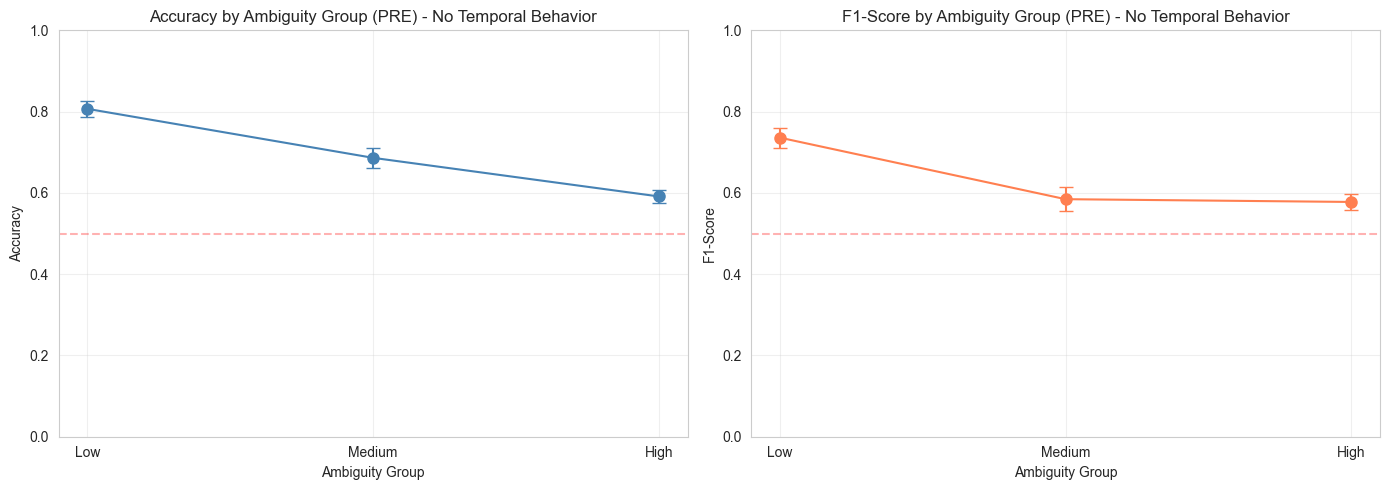

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy with SEM error bars
ax = axes[0]
ax.errorbar(comparison_df['Group'], comparison_df['Accuracy'], 
            yerr=comparison_df['Accuracy_SEM'], fmt='o-', capsize=5, color='steelblue', markersize=8)
ax.set_xlabel('Ambiguity Group')
ax.set_ylabel('Accuracy')
ax.set_title(f'Accuracy by Ambiguity Group ({TIMEFRAME}) - No Temporal Behavior')
ax.set_ylim([0, 1])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax.grid(alpha=0.3)

# F1-Score with SEM error bars
ax = axes[1]
ax.errorbar(comparison_df['Group'], comparison_df['F1-Score'], 
            yerr=comparison_df['F1_SEM'], fmt='o-', capsize=5, color='coral', markersize=8)
ax.set_xlabel('Ambiguity Group')
ax.set_ylabel('F1-Score')
ax.set_title(f'F1-Score by Ambiguity Group ({TIMEFRAME}) - No Temporal Behavior')
ax.set_ylim([0, 1])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Subject-Level Accuracy Distributions

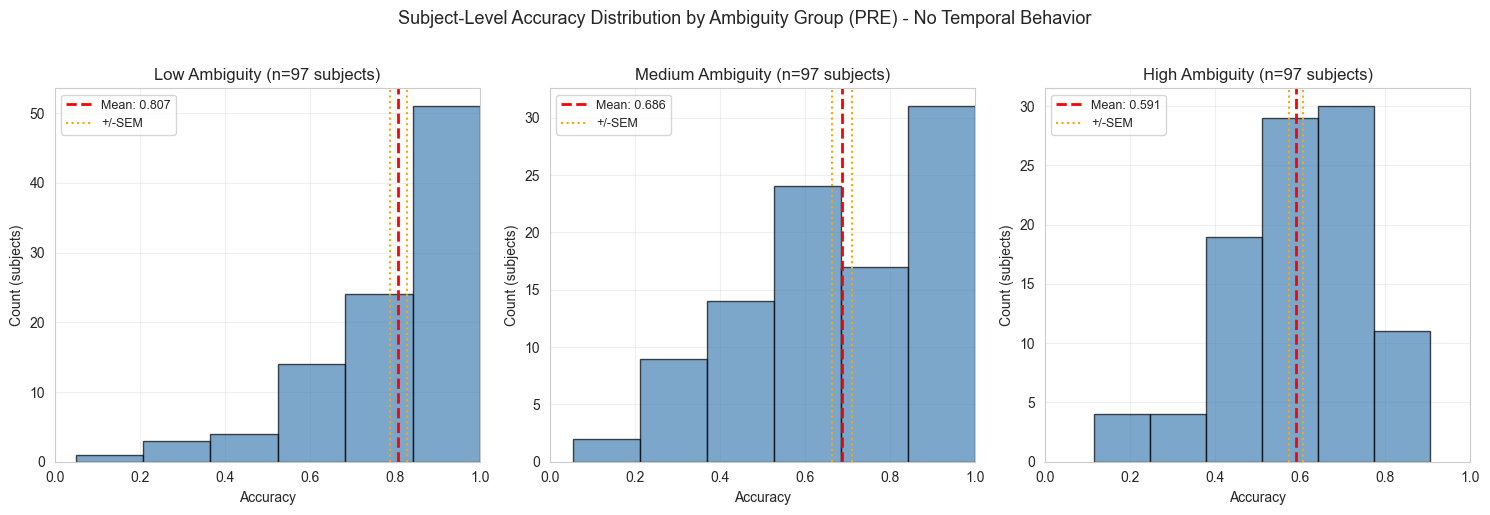

In [8]:
# Plot subject-level accuracy distributions for each ambiguity group
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (group, results) in enumerate(group_results.items()):
    ax = axes[idx]
    subject_accs = results['accuracy_per_subject']
    
    # Histogram
    ax.hist(subject_accs, bins=6, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(results['accuracy_mean'], color='red', linestyle='--', linewidth=2,
               label=f"Mean: {results['accuracy_mean']:.3f}")
    ax.axvline(results['accuracy_mean'] - results['accuracy_sem'], color='orange',
               linestyle=':', linewidth=1.5, label=f"+/-SEM")
    ax.axvline(results['accuracy_mean'] + results['accuracy_sem'], color='orange',
               linestyle=':', linewidth=1.5)
    
    ax.set_xlabel('Accuracy')
    ax.set_ylabel('Count (subjects)')
    ax.set_title(f'{group} Ambiguity (n={results["n_subjects"]} subjects)')
    ax.set_xlim([0, 1])
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(f'Subject-Level Accuracy Distribution by Ambiguity Group ({TIMEFRAME}) - No Temporal Behavior', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

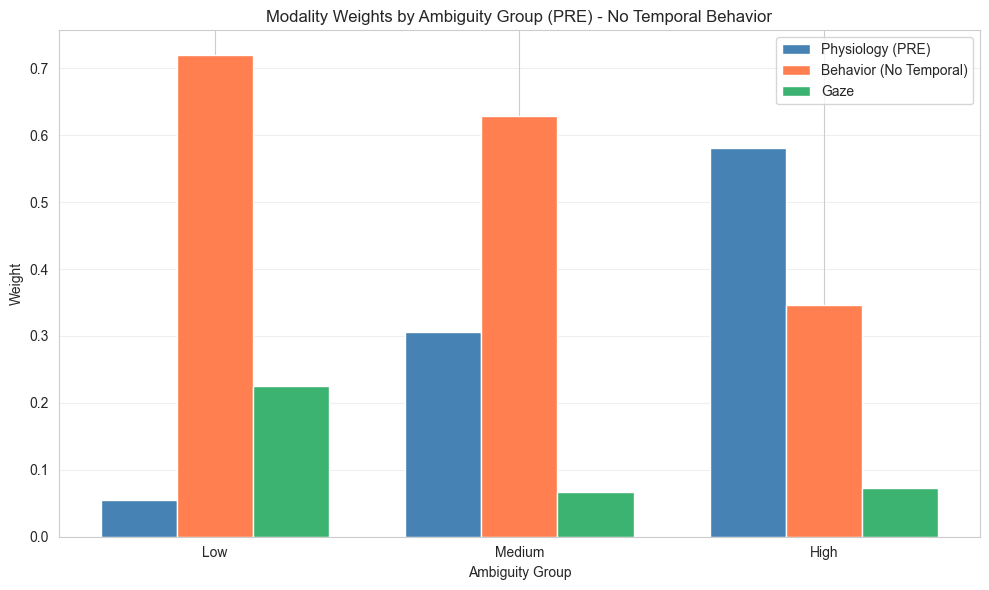

In [9]:
# Modality weights by group
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_df))
width = 0.25

ax.bar(x - width, comparison_df['Physiology_Weight'], width, 
       label=f'Physiology ({TIMEFRAME})', color='steelblue')
ax.bar(x, comparison_df['Behavior_Weight'], width, 
       label='Behavior (No Temporal)', color='coral')
ax.bar(x + width, comparison_df['Gaze_Weight'], width, 
       label='Gaze', color='mediumseagreen')

ax.set_xlabel('Ambiguity Group')
ax.set_ylabel('Weight')
ax.set_title(f'Modality Weights by Ambiguity Group ({TIMEFRAME}) - No Temporal Behavior')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Group'])
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Save Results to CSV

Exporting all results for later analysis without re-running.

In [10]:
import os
os.makedirs(f'../../data/results/fusion_model_results_no_temporal_{TIMEFRAME}', exist_ok=True)

# Save comparison results across groups
if 'comparison_df' in locals() and comparison_df is not None:
    output_file = f'../../data/results/fusion_model_results_no_temporal_{TIMEFRAME}/ambiguity_group_no_temporal_{TIMEFRAME}_comparison.csv'
    comparison_df.to_csv(output_file, index=False)
    print(f"Saved comparison results to: {output_file}")
    print(f"  Contains {len(comparison_df)} groups")

# Save detailed group results
if 'group_results' in locals() and group_results:
    for group_name, results in group_results.items():
        # Save modality weights
        modality_names = results.get('modality_names', ['Physiology', 'Behavior', 'Gaze'][:len(results['weights'])])
        weights_df = pd.DataFrame({
            'Modality': modality_names,
            'Weight': results['weights']
        })
        weights_file = f'../../data/results/fusion_model_results_no_temporal_{TIMEFRAME}/ambiguity_group_no_temporal_{TIMEFRAME}_{group_name}_weights.csv'
        weights_df.to_csv(weights_file, index=False)

        # Save subject-level accuracies if available
        if 'accuracy_per_subject' in results:
            subject_df = pd.DataFrame({
                'accuracy': results['accuracy_per_subject'],
                'f1_score': results.get('f1_per_subject', [])
            })
            subject_file = f'../../data/results/fusion_model_results_no_temporal_{TIMEFRAME}/ambiguity_group_no_temporal_{TIMEFRAME}_{group_name}_subject_accuracies.csv'
            subject_df.to_csv(subject_file, index=False)

    print(f"Saved detailed results for {len(group_results)} groups")

# Save excluded features info
excluded_info = pd.DataFrame({
    'excluded_feature': excluded_features,
    'reason': ['temporal/grouping variable'] * len(excluded_features)
})
excluded_info.to_csv(f'../../data/results/fusion_model_results_no_temporal_{TIMEFRAME}/ambiguity_group_no_temporal_{TIMEFRAME}_excluded_features.csv', index=False)

print(f"\nAll results saved to: ../../data/results/fusion_model_results_no_temporal_{TIMEFRAME}/")

Saved comparison results to: ../../data/results/fusion_model_results_no_temporal_PRE/ambiguity_group_no_temporal_PRE_comparison.csv
  Contains 3 groups
Saved detailed results for 3 groups

All results saved to: ../../data/results/fusion_model_results_no_temporal_PRE/


## 9. Feature Importance Analysis (SHAP) by Ambiguity Group

Compute SHAP values for each modality within each ambiguity group to see how feature importance changes with task difficulty.

In [ ]:
import shap
from src.utils.config import get_model_params

def train_and_get_shap(X, y, subjects, feature_names, model_name="Model"):
    """Train RF model with LOSO CV and compute SHAP values."""
    logo = LeaveOneGroupOut()
    all_shap_values = []
    all_test_indices = []
    model_params = get_model_params('random_forest')
    
    fold_count = 0
    for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, subjects)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]
        
        rf = RandomForestClassifier(**model_params)
        rf.fit(X_train, y_train)
        
        explainer = shap.TreeExplainer(rf)
        shap_values_fold = explainer.shap_values(X_test)
        
        if isinstance(shap_values_fold, list):
            shap_values_fold = shap_values_fold[1]
        if len(shap_values_fold.shape) == 3:
            shap_values_fold = shap_values_fold[:, :, 1]
        if len(shap_values_fold.shape) == 1:
            shap_values_fold = shap_values_fold.reshape(1, -1)
        
        all_shap_values.append(shap_values_fold)
        all_test_indices.extend(test_idx)
        fold_count += 1
    
    shap_values_array = np.vstack(all_shap_values)
    mean_abs_shap = np.abs(shap_values_array).mean(axis=0)
    if len(mean_abs_shap.shape) > 1:
        mean_abs_shap = mean_abs_shap.flatten()
    
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False)
    
    return shap_values_array, feature_importance_df, X[all_test_indices]

# Helper functions
def get_modality_color(feature):
    if feature in physio_cols:
        return 'steelblue'
    elif feature in behavior_cols:
        return 'forestgreen'
    elif feature in gaze_cols:
        return 'darkorange'
    return 'gray'

def get_modality_name(feature):
    if feature in physio_cols:
        return 'Physiology'
    elif feature in behavior_cols:
        return 'Behavior'
    elif feature in gaze_cols:
        return 'Gaze'
    return 'Unknown'

In [ ]:
# Compute SHAP values for each ambiguity group
print("Computing SHAP feature importance for each ambiguity group...")
print("(This may take several minutes)\n")

group_shap_results = {}
all_feature_cols = physio_cols + behavior_cols + (gaze_cols if len(gaze_cols) > 0 else [])

for group in ['Low', 'Medium', 'High']:
    print(f"\n{'='*60}")
    print(f"Computing SHAP for {group} Ambiguity Group")
    print(f"{'='*60}")
    
    # Filter data for this group
    group_df = merged_df[merged_df['ambiguity_group'] == group].copy()
    
    # Prepare feature matrices
    imputer = SimpleImputer(strategy='mean')
    X_physio = imputer.fit_transform(group_df[physio_cols])
    X_behavior = imputer.fit_transform(group_df[behavior_cols])
    X_gaze = imputer.fit_transform(group_df[gaze_cols]) if len(gaze_cols) > 0 else np.zeros((len(group_df), 1))
    
    # Combine all features
    X_all = np.hstack([X_physio, X_behavior] + ([X_gaze] if len(gaze_cols) > 0 else []))
    y = group_df['outcome'].values
    subjects = group_df['subject_id'].values
    
    # Compute SHAP
    shap_vals, importance_df, _ = train_and_get_shap(
        X_all, y, subjects, all_feature_cols, f"{group} Ambiguity"
    )
    
    group_shap_results[group] = importance_df
    
    print(f"\nTop 10 features for {group} Ambiguity:")
    print(importance_df.head(10).to_string(index=False))

In [ ]:
# Visualize top features comparison across ambiguity groups
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for idx, (group, importance_df) in enumerate(group_shap_results.items()):
    ax = axes[idx]
    top_10 = importance_df.head(10)
    colors = [get_modality_color(f) for f in top_10['feature']]
    
    ax.barh(range(len(top_10)), top_10['mean_abs_shap'], color=colors)
    ax.set_yticks(range(len(top_10)))
    ax.set_yticklabels(top_10['feature'])
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP|')
    ax.set_title(f'{group} Ambiguity\n(n={len(merged_df[merged_df["ambiguity_group"]==group])} trials)')

legend_elements = [
    Patch(facecolor='steelblue', label='Physiology'),
    Patch(facecolor='darkorange', label='Gaze'),
    Patch(facecolor='forestgreen', label='Behavior')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))
plt.suptitle(f'Top 10 Features by Ambiguity Group ({TIMEFRAME}) - No Temporal Behavior', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'../../data/results/fusion_model_results_no_temporal_{TIMEFRAME}/shap_by_ambiguity_group_{TIMEFRAME}.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Save SHAP results
for group, importance_df in group_shap_results.items():
    importance_df.to_csv(
        f'../../data/results/fusion_model_results_no_temporal_{TIMEFRAME}/shap_importance_{group}_ambiguity_{TIMEFRAME}.csv',
        index=False
    )
print(f"\n✓ Saved SHAP importance for all ambiguity groups")